# MITgcm Support in Nereus

This notebook demonstrates loading and working with MITgcm LLC90 output using nereus.

In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import nereus as nr
import numpy as np

data_path = "/Users/nkolduno/PYTHON/DATA/MITgcm/"

## Load mesh

In [2]:
mesh = nr.mitgcm.load_mesh(data_path)
mesh

<xarray.Dataset> Size: 3MB
Dimensions:          (npoints: 105300, depth_level: 50)
Dimensions without coordinates: npoints, depth_level
Data variables:
    lon              (npoints) float64 842kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lat              (npoints) float64 842kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    area             (npoints) float64 842kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    depth            (depth_level) float64 400B 5.0 15.0 ... 5.461e+03 5.906e+03
    layer_thickness  (depth_level) float64 400B 10.0 10.0 10.0 ... 433.5 456.5
    bathymetry       (npoints) float64 842kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    nx:                   90
    ny:                   1170
    original_shape:       (1170, 90)
    nereus_mesh_type:     mitgcm
    nereus_mesh_version:  1.0
    nereus_dask_backend:  False
    nereus_source_path:   /Users/nkolduno/PYTHON/DATA/MITgcm

In [3]:
# Auto-detection also works
mesh_auto = nr.load_mesh(data_path)
mesh_auto.attrs["nereus_mesh_type"]

'mitgcm'

## Load diagnostics

In [4]:
# Load 2D diagnostics
ds2d = nr.mitgcm.open_dataset(data_path, prefix="diags2D",
    delta_t=3600, ref_date="1710-1-1", mesh=mesh)
ds2d

<xarray.Dataset> Size: 8MB
Dimensions:   (time: 2, npoints: 105300, depth_level: 50)
Coordinates:
  * time      (time) datetime64[ns] 16B 1711-01-01 1712-01-01
    lon       (npoints) float64 842kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lat       (npoints) float64 842kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    depth     (depth_level) float64 400B 5.0 15.0 25.0 ... 5.461e+03 5.906e+03
Dimensions without coordinates: npoints, depth_level
Data variables:
    ETAN      (time, npoints) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    MXLDEPTH  (time, npoints) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    oceFWflx  (time, npoints) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    oceQnet   (time, npoints) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [5]:
# Load 3D diagnostics
ds3d = nr.mitgcm.open_dataset(data_path, prefix="diags3D",
    delta_t=3600, ref_date="1710-1-1", mesh=mesh)
ds3d

<xarray.Dataset> Size: 591MB
Dimensions:   (time: 2, depth_level: 50, npoints: 105300)
Coordinates:
  * time      (time) datetime64[ns] 16B 1711-01-01 1712-01-01
    lon       (npoints) float64 842kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lat       (npoints) float64 842kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    depth     (depth_level) float64 400B 5.0 15.0 25.0 ... 5.461e+03 5.906e+03
Dimensions without coordinates: depth_level, npoints
Data variables:
    THETA     (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    SALT      (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    DRHODR    (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    UVEL      (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    VVEL      (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    WVEL      (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    LaTr1RHO  (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0

In [6]:
# Load all prefixes at once
ds_all = nr.mitgcm.open_dataset(data_path,
    prefix=["diags2D", "diags3D", "diagsGGL90", "diagsKrN2"],
    delta_t=3600, ref_date="1710-1-1", mesh=mesh)
print(f"Variables: {list(ds_all.data_vars)}")
print(f"Time steps: {ds_all.time.values}")
ds_all

Variables: ['ETAN', 'MXLDEPTH', 'oceFWflx', 'oceQnet', 'THETA', 'SALT', 'DRHODR', 'UVEL', 'VVEL', 'WVEL', 'LaTr1RHO', 'GGL90TKE', 'GGL90Lmx', 'GGL90Prl', 'GGL90Kr', 'GGL90ArU', 'GGL90ArV', 'GGL90KN2']
Time steps: ['1711-01-01T00:00:00.000000000' '1712-01-01T00:00:00.000000000']


<xarray.Dataset> Size: 1GB
Dimensions:   (time: 2, npoints: 105300, depth_level: 50)
Coordinates:
  * time      (time) datetime64[ns] 16B 1711-01-01 1712-01-01
    lon       (npoints) float64 842kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lat       (npoints) float64 842kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    depth     (depth_level) float64 400B 5.0 15.0 25.0 ... 5.461e+03 5.906e+03
Dimensions without coordinates: npoints, depth_level
Data variables: (12/18)
    ETAN      (time, npoints) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    MXLDEPTH  (time, npoints) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    oceFWflx  (time, npoints) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    oceQnet   (time, npoints) float64 2MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    THETA     (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    SALT      (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    ...        ...
    GGL90Lmx  (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    GGL90Prl  (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    GGL90Kr   (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    GGL90ArU  (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    GGL90ArV  (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0
    GGL90KN2  (time, depth_level, npoints) float64 84MB 0.0 0.0 0.0 ... 0.0 0.0

## Plotting

Text(0.5, 1.0, 'Sea Surface Temperature (THETA, level 0)')

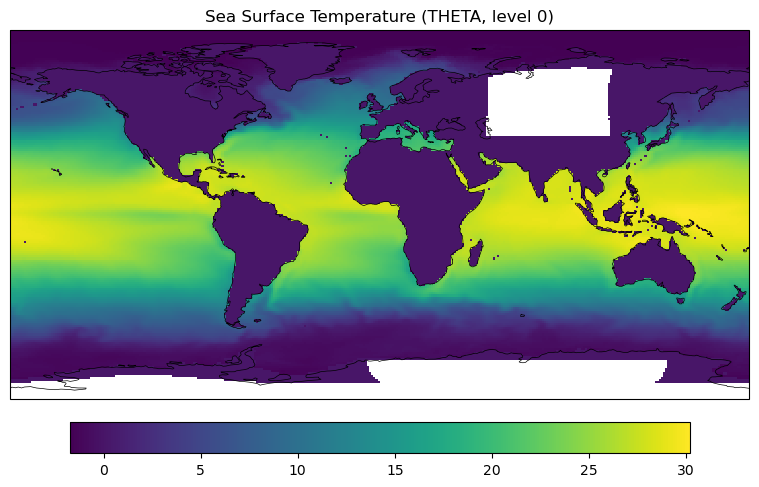

In [7]:
# Plot SST (first timestep)
sst = ds3d["THETA"].isel(time=0, depth_level=0).values
fig, ax, interp = nr.plot(sst, mesh["lon"].values, mesh["lat"].values)
ax.set_title("Sea Surface Temperature (THETA, level 0)")

Text(0.5, 1.0, 'Mixed Layer Depth')

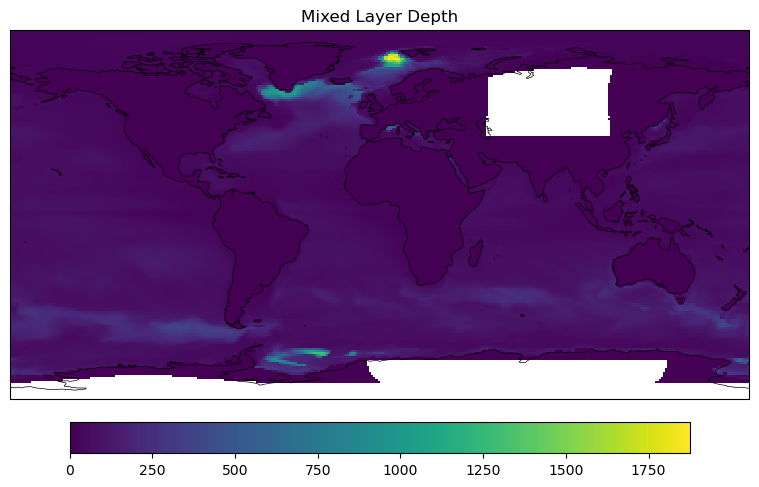

In [8]:
# Plot mixed layer depth
mld = ds2d["MXLDEPTH"].isel(time=0).values
fig, ax, _ = nr.plot(mld, mesh["lon"].values, mesh["lat"].values)
ax.set_title("Mixed Layer Depth")

Text(0.5, 1.0, 'Sea Surface Height (ETAN)')

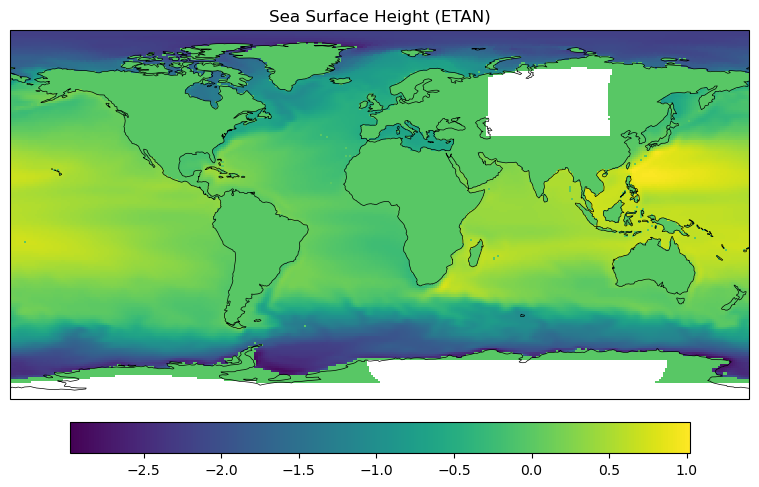

In [9]:
# Plot sea surface height
eta = ds2d["ETAN"].isel(time=0).values
fig, ax, _ = nr.plot(eta, mesh["lon"].values, mesh["lat"].values)
ax.set_title("Sea Surface Height (ETAN)")

## Diagnostics

In [10]:
# Surface mean SST
sst = ds3d["THETA"].isel(time=0, depth_level=0).values
mean_sst = nr.surface_mean(sst, mesh["area"].values)
print(f"Global mean SST: {mean_sst:.2f} \u00b0C")

Global mean SST: 13.41 °C


In [11]:
# Depth levels and layer thickness
print("Depth levels (m):", mesh["depth"].values)
print("Layer thickness (m):", mesh["layer_thickness"].values)

Depth levels (m): [5.00000000e+00 1.50000000e+01 2.50000000e+01 3.50000000e+01
 4.50000000e+01 5.50000000e+01 6.50000000e+01 7.50049973e+01
 8.50250015e+01 9.50950012e+01 1.05309998e+02 1.15870003e+02
 1.27150002e+02 1.39740005e+02 1.54470001e+02 1.72399994e+02
 1.94735001e+02 2.22710007e+02 2.57470001e+02 2.99929993e+02
 3.50679993e+02 4.09929993e+02 4.77470001e+02 5.52710022e+02
 6.34734985e+02 7.22400024e+02 8.14469971e+02 9.09739990e+02
 1.00715503e+03 1.10590503e+03 1.20553503e+03 1.30620496e+03
 1.40915002e+03 1.51709497e+03 1.63417505e+03 1.76513501e+03
 1.91415002e+03 2.08403491e+03 2.27622510e+03 2.49125000e+03
 2.72925000e+03 2.99025000e+03 3.27425000e+03 3.58125000e+03
 3.91125000e+03 4.26425000e+03 4.64025000e+03 5.03925000e+03
 5.46125000e+03 5.90625000e+03]
Layer thickness (m): [ 10.          10.          10.          10.          10.
  10.          10.          10.01000023  10.02999973  10.10999966
  10.31999969  10.80000019  11.76000023  13.42000008  16.04000092
  19.81

Closest depth to 100m: 95.1m (index 9)


Text(0.5, 1.0, 'Temperature at 95m depth')

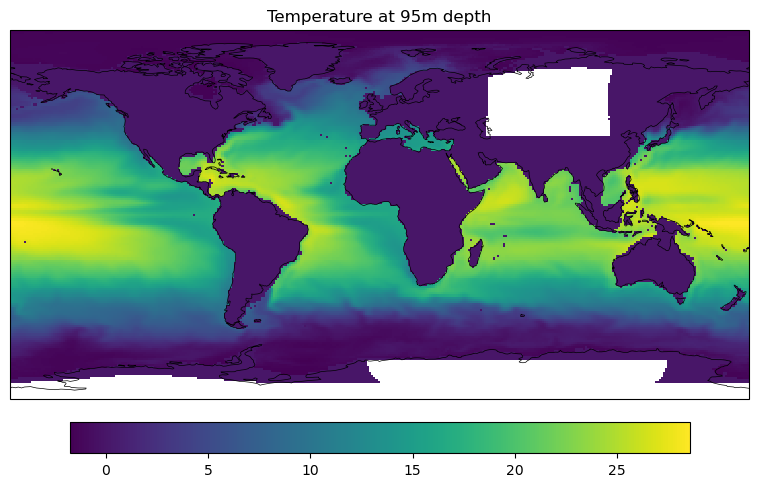

In [12]:
# Temperature at a specific depth (~100m)
idx, depth_val = nr.find_closest_depth(mesh["depth"].values, 100)
print(f"Closest depth to 100m: {depth_val:.1f}m (index {idx})")
temp_100m = ds3d["THETA"].isel(time=0, depth_level=idx).values
fig, ax, _ = nr.plot(temp_100m, mesh["lon"].values, mesh["lat"].values)
ax.set_title(f"Temperature at {depth_val:.0f}m depth")

## Projections and regridding

Text(0.5, 1.0, 'Arctic SST')

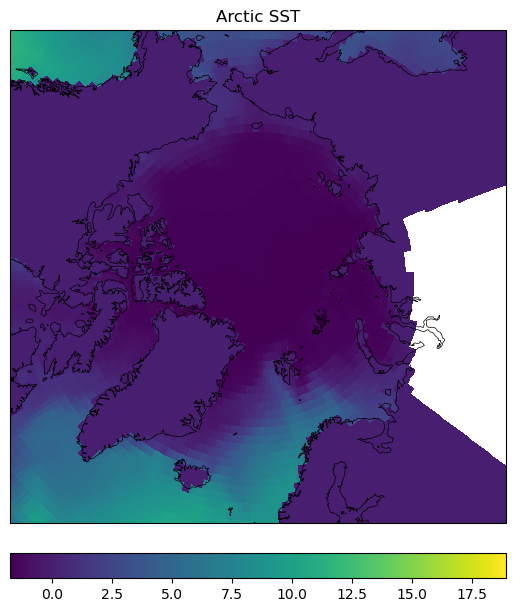

In [13]:
# Arctic view
sst = ds3d["THETA"].isel(time=0, depth_level=0).values
fig, ax, _ = nr.plot(sst, mesh["lon"].values, mesh["lat"].values,
    projection="npstere", extent=[-180, 180, 60, 90])
ax.set_title("Arctic SST")

In [14]:
# Regrid to regular grid
sst = ds3d["THETA"].isel(time=0, depth_level=0).values
regridded, interp = nr.regrid(sst, mesh["lon"].values, mesh["lat"].values,
    resolution=1.0)
print(f"Regridded shape: {regridded.shape}")

Regridded shape: (180, 360)


Text(0.5, 1.0, 'Bathymetry (m)')

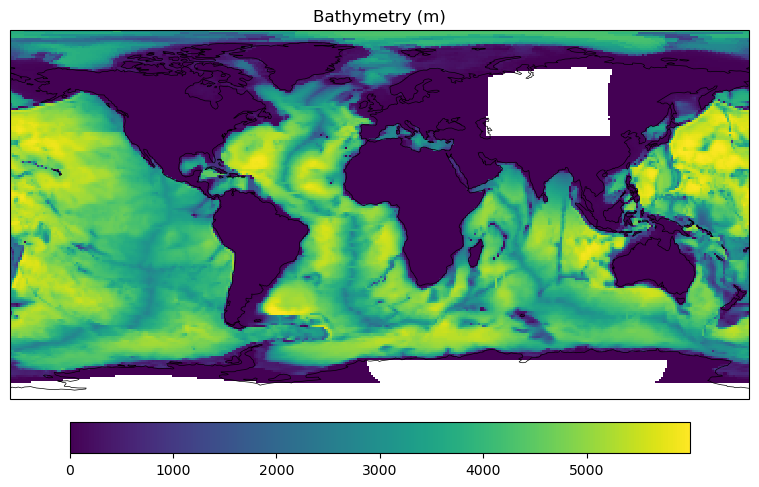

In [15]:
# Bathymetry
fig, ax, _ = nr.plot(mesh["bathymetry"].values,
    mesh["lon"].values, mesh["lat"].values)
ax.set_title("Bathymetry (m)")

In [16]:
# Load mesh with land mask
mesh_m = nr.mitgcm.load_mesh(data_path, mask_land=True)
print(f"Land points: {mesh_m['land_mask'].values.sum()}")
print(f"Ocean points: {(~mesh_m['land_mask'].values).sum()}")
print(f"hFacC shape: {mesh_m['hFacC'].shape}")
print(f"Partial cells: {((mesh_m['hFacC'].values > 0) & (mesh_m['hFacC'].values < 1)).sum()}")
mesh_m

Land points: 44674
Ocean points: 60626
hFacC shape: (50, 105300)
Partial cells: 53864


<xarray.Dataset> Size: 46MB
Dimensions:          (npoints: 105300, depth_level: 50)
Dimensions without coordinates: npoints, depth_level
Data variables:
    lon              (npoints) float64 842kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    lat              (npoints) float64 842kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    area             (npoints) float64 842kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    depth            (depth_level) float64 400B 5.0 15.0 ... 5.461e+03 5.906e+03
    layer_thickness  (depth_level) float64 400B 10.0 10.0 10.0 ... 433.5 456.5
    bathymetry       (npoints) float64 842kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    land_mask        (npoints) bool 105kB True True True True ... True True True
    hFacC            (depth_level, npoints) float64 42MB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    nx:                   90
    ny:                   1170
    original_shape:       (1170, 90)
    nereus_mesh_type:     mitgcm
    nereus_mesh_version:  1.0
    nereus_dask_backend:  False
    nereus_source_path:   /Users/nkolduno/PYTHON/DATA/MITgcm

In [17]:
# Load data with land masking — zeros on land become NaN
ds3d_m = nr.mitgcm.open_dataset(data_path, prefix="diags3D",
    delta_t=3600, ref_date="1710-1-1", mesh=mesh_m, mask_land=True)

sst_masked = ds3d_m["THETA"].isel(time=0, depth_level=0).values
print(f"SST range: {np.nanmin(sst_masked):.2f} to {np.nanmax(sst_masked):.2f}")
print(f"NaN (land): {np.isnan(sst_masked).sum()}, valid (ocean): {(~np.isnan(sst_masked)).sum()}")

SST range: -1.75 to 30.17
NaN (land): 44674, valid (ocean): 60626


Text(0.5, 1.0, 'mask_land=True (land = NaN)')

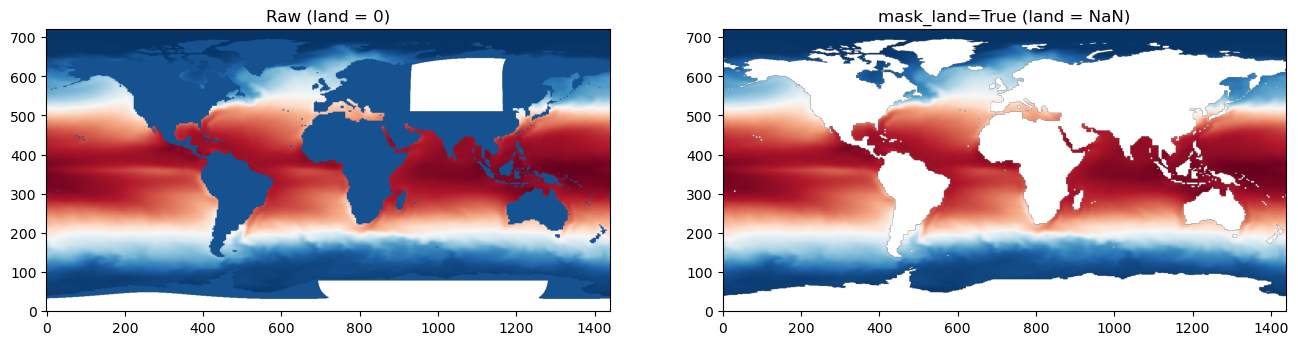

In [21]:
# Compare: SST without vs with land masking
fig, axes = __import__('matplotlib').pyplot.subplots(1, 2, figsize=(16, 4))

sst_raw = ds3d["THETA"].isel(time=0, depth_level=0).values
regridded_raw, interp = nr.regrid(sst_raw, mesh["lon"].values, mesh["lat"].values, resolution=0.25)
regridded_masked, _ = nr.regrid(sst_masked, mesh_m["lon"].values, mesh_m["lat"].values, resolution=0.25)

axes[0].imshow(regridded_raw, origin="lower", vmin=-2, vmax=30, cmap="RdBu_r")
axes[0].set_title("Raw (land = 0)")
axes[1].imshow(regridded_masked, origin="lower", vmin=-2, vmax=30, cmap="RdBu_r")
axes[1].set_title("mask_land=True (land = NaN)")

In [20]:
# You can also apply the mask manually to any variable
# using xarray .where() with the mesh masks
sst_manual = ds3d["THETA"].isel(time=0, depth_level=0).where(~mesh_m["land_mask"])
print(f"Manual masking NaN count: {sst_manual.isnull().sum().values}")

Manual masking NaN count: 44674
